# 🧠 Deep Learning Fundamentals — Complete Revision Notebook
### Module 5 | Day 1 — Artificial Neural Networks (ANN)

This notebook builds a **Neural Network completely from scratch using NumPy** — no black-box
frameworks — so every concept (forward propagation, backpropagation, gradient descent, optimizers,
regularization) is fully transparent and verifiable. It closes with practical **ANN classification
and regression** using Scikit-learn's `MLPClassifier` / `MLPRegressor`.

**Roadmap:**
1. What is a Neural Network?
2. The Perceptron — the original building block
3. Network Architecture
4. Activation Functions
5. Forward Propagation
6. Loss Functions
7. Backpropagation & Gradient Descent (building a full NumPy engine)
8. Batch vs Mini-Batch vs Stochastic Gradient Descent
9. Epochs, Batch Size, Iterations
10. Optimizers — SGD, Momentum, RMSProp, Adam
11. Weight Initialization (Xavier, He)
12. Vanishing / Exploding Gradients
13. Preventing Overfitting — Dropout, L1/L2, Early Stopping, Batch Normalization
14. Learning Rate & Scheduling
15. Hyperparameter Tuning
16. Practice — ANN for Classification
17. Practice — ANN for Regression
18. Key Takeaways


## 🐍 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_regression, make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
np.random.seed(42)

print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 1. What is a Neural Network?

A **Neural Network** is a function made of stacked layers of simple units ("neurons") that learn to
map inputs to outputs by adjusting internal weights based on data — inspired loosely by biological
neurons.

Every neuron does the same simple thing:

```
output = activation(weighted_sum_of_inputs + bias)
```

Stack enough of these, and the network can approximate extremely complex functions — this is the
basis of **Deep Learning** (Deep = many layers).


## 2. The Perceptron — The Original Building Block

The **Perceptron** (Rosenblatt, 1958) is the simplest possible neural network: a single neuron that
draws a straight line (a linear decision boundary) to separate two classes.

Update rule for each misclassified point:

```
w = w + lr * (y_true - y_pred) * x
b = b + lr * (y_true - y_pred)
```

Let's implement and train one from scratch on a linearly separable dataset.


In [2]:
class Perceptron:
    def __init__(self, lr=0.1, n_iters=50):
        self.lr = lr
        self.n_iters = n_iters

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.errors_per_epoch = []

        for _ in range(self.n_iters):
            errors = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi)
                update = self.lr * (yi - y_pred)
                self.w += update * xi
                self.b += update
                errors += int(update != 0.0)
            self.errors_per_epoch.append(errors)
        return self

    def net_input(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return np.where(self.net_input(X) >= 0, 1, 0)

# Linearly separable toy dataset
X_lin, y_lin = make_classification(
    n_samples=100, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=2.0, random_state=42
)

perceptron = Perceptron(lr=0.1, n_iters=20).fit(X_lin, y_lin)
print("Final training errors per epoch:", perceptron.errors_per_epoch[-5:])


Final training errors per epoch: [0, 0, 0, 0, 0]


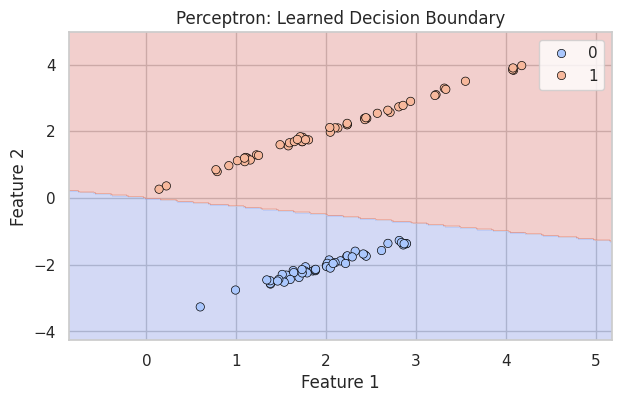

In [3]:
# Visualize the learned decision boundary
xx, yy = np.meshgrid(
    np.linspace(X_lin[:, 0].min()-1, X_lin[:, 0].max()+1, 200),
    np.linspace(X_lin[:, 1].min()-1, X_lin[:, 1].max()+1, 200)
)
grid_preds = perceptron.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, grid_preds, alpha=0.25, cmap="coolwarm")
sns.scatterplot(x=X_lin[:, 0], y=X_lin[:, 1], hue=y_lin, palette="coolwarm", edgecolor="black")
plt.title("Perceptron: Learned Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 3. Network Architecture

A Neural Network is organized into layers:

| Layer | Role |
|---|---|
| **Input Layer** | Receives the raw features (no computation) |
| **Hidden Layer(s)** | Learn intermediate representations via weighted sums + activations |
| **Output Layer** | Produces the final prediction (class probability or continuous value) |

```
Input (features) -> Hidden Layer 1 -> Hidden Layer 2 -> ... -> Output Layer -> Prediction
```

Each connection between neurons has a **weight**; each neuron has a **bias**. Training means finding
the weights and biases that minimize prediction error.


## 4. Activation Functions

Without a non-linear activation function, stacking layers would collapse into a single linear
transformation — no matter how many layers, the network could only learn straight lines. Activations
introduce the non-linearity that lets networks learn complex patterns.


Softmax example (turns scores into probabilities that sum to 1):
[[0.659 0.242 0.099]]


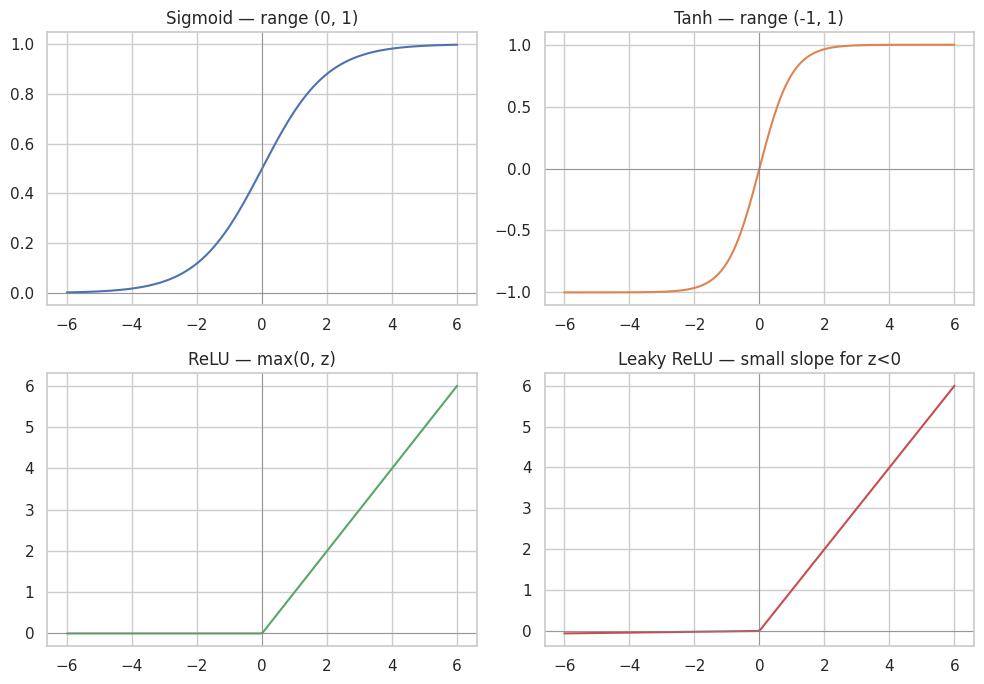

In [4]:
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def tanh(z): return np.tanh(z)
def relu(z): return np.maximum(0, z)
def leaky_relu(z, alpha=0.01): return np.where(z > 0, z, alpha * z)
def softmax(z):
    z = z - np.max(z, axis=-1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=-1, keepdims=True)

z = np.linspace(-6, 6, 200)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0,0].plot(z, sigmoid(z), color="#4C72B0"); axes[0,0].set_title("Sigmoid — range (0, 1)")
axes[0,1].plot(z, tanh(z), color="#DD8452"); axes[0,1].set_title("Tanh — range (-1, 1)")
axes[1,0].plot(z, relu(z), color="#55A868"); axes[1,0].set_title("ReLU — max(0, z)")
axes[1,1].plot(z, leaky_relu(z), color="#C44E52"); axes[1,1].set_title("Leaky ReLU — small slope for z<0")
for ax in axes.flat:
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

print("Softmax example (turns scores into probabilities that sum to 1):")
print(np.round(softmax(np.array([[2.0, 1.0, 0.1]])), 3))


| Activation | Typical use |
|---|---|
| **Sigmoid** | Binary classification output layer |
| **Tanh** | Hidden layers (zero-centered, but still saturates) |
| **ReLU** | Default choice for hidden layers in modern deep nets |
| **Leaky ReLU** | Fixes ReLU's "dying neuron" problem for negative inputs |
| **Softmax** | Multi-class classification output layer |


## 5. Forward Propagation

**Forward Propagation** is the process of passing input data through the network, layer by layer, to
produce a prediction. At each layer: `Z = A_prev @ W + b`, then `A = activation(Z)`.


In [5]:
# Manual forward pass through a tiny 2-layer network (4 inputs -> 3 hidden -> 1 output)
np.random.seed(1)
X_demo = np.random.randn(5, 4)          # 5 samples, 4 features

W1 = np.random.randn(4, 3) * 0.5
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1) * 0.5
b2 = np.zeros((1, 1))

Z1 = X_demo @ W1 + b1
A1 = relu(Z1)
Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)

print("Hidden layer activations (A1):\n", np.round(A1, 3))
print("\nOutput predictions (A2):\n", np.round(A2, 3))


Hidden layer activations (A1):
 [[0.    1.272 1.225]
 [0.    0.    1.094]
 [0.    0.099 0.442]
 [0.    0.    0.052]
 [0.026 0.    0.101]]

Output predictions (A2):
 [[0.279]
 [0.409]
 [0.453]
 [0.496]
 [0.489]]


## 6. Loss Functions

A **Loss Function** quantifies how wrong the network's predictions are. Training = minimizing this
loss.

| Loss | Formula | Used for |
|---|---|---|
| **MSE** | mean((y - ŷ)²) | Regression |
| **Binary Cross-Entropy** | -mean(y·log(ŷ) + (1-y)·log(1-ŷ)) | Binary classification |
| **Categorical Cross-Entropy** | -mean(Σ y·log(ŷ)) | Multi-class classification |


In [6]:
def mse(y_true, y_pred): return np.mean((y_true - y_pred) ** 2)

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -np.mean(y_true*np.log(y_pred+eps) + (1-y_true)*np.log(1-y_pred+eps))

def categorical_cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

# Example
y_true_bin = np.array([1, 0, 1, 1])
y_pred_bin = np.array([0.9, 0.2, 0.6, 0.4])
print("Binary Cross-Entropy:", round(binary_cross_entropy(y_true_bin, y_pred_bin), 4))

y_true_num = np.array([3.0, 5.0, 2.5])
y_pred_num = np.array([2.8, 5.5, 2.0])
print("MSE:", round(mse(y_true_num, y_pred_num), 4))


Binary Cross-Entropy: 0.4389
MSE: 0.18


## 7. Backpropagation & Gradient Descent — Building a Full NumPy Engine

**Backpropagation** computes how much each weight contributed to the error, using the **chain rule**,
working backward from the output layer to the input layer. **Gradient Descent** then updates every
weight in the direction that reduces the loss:

```
w = w - learning_rate * dL/dw
```

Below is a complete, configurable `DenseNN` class supporting multiple layers, activations,
optimizers, dropout, and L2 regularization — everything used throughout the rest of this notebook.


In [7]:
ACT = {
    "sigmoid": (sigmoid, lambda a: a * (1 - a)),
    "relu":    (relu,    lambda a: (a > 0).astype(float)),
    "tanh":    (tanh,    lambda a: 1 - a**2),
    "leaky_relu": (leaky_relu, lambda a: np.where(a > 0, 1, 0.01)),
}

class DenseNN:
    """A fully configurable multi-layer perceptron trained via manual backpropagation."""

    def __init__(self, layer_sizes, activations, optimizer="adam", lr=0.01,
                 l2=0.0, dropout=0.0, init="he"):
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.optimizer = optimizer
        self.lr = lr
        self.l2 = l2
        self.dropout = dropout
        self.init = init
        self._init_params()
        self._init_optimizer_state()

    def _init_params(self):
        self.W, self.b = [], []
        for i in range(len(self.layer_sizes) - 1):
            fan_in, fan_out = self.layer_sizes[i], self.layer_sizes[i+1]
            if self.init == "he":
                scale = np.sqrt(2 / fan_in)
            elif self.init == "xavier":
                scale = np.sqrt(1 / fan_in)
            elif self.init == "zero":
                scale = 0.0
            else:
                scale = 0.01
            self.W.append(np.random.randn(fan_in, fan_out) * scale)
            self.b.append(np.zeros((1, fan_out)))

    def _init_optimizer_state(self):
        self.mW = [np.zeros_like(w) for w in self.W]
        self.mb = [np.zeros_like(b) for b in self.b]
        self.vW = [np.zeros_like(w) for w in self.W]
        self.vb = [np.zeros_like(b) for b in self.b]
        self.t = 0

    def forward(self, X, training=False):
        self.A, self.masks = [X], []
        a = X
        for i in range(len(self.W)):
            z = a @ self.W[i] + self.b[i]
            act_name = self.activations[i]
            a = softmax(z) if act_name == "softmax" else ACT[act_name][0](z)
            if training and self.dropout > 0 and i < len(self.W) - 1:
                mask = (np.random.rand(*a.shape) > self.dropout) / (1 - self.dropout)
                a = a * mask
                self.masks.append(mask)
            else:
                self.masks.append(None)
            self.A.append(a)
        return a

    def backward(self, X, y, loss="bce"):
        m = X.shape[0]
        L = len(self.W)
        dW, db = [None]*L, [None]*L
        dz = self.A[-1] - y  # valid for BCE/CCE + matching output activation, and for MSE (scaled below)
        if loss == "mse":
            dz = dz * 2 / m

        for i in reversed(range(L)):
            a_prev = self.A[i]
            dW[i] = a_prev.T @ dz / m + self.l2 * self.W[i] / m
            db[i] = np.sum(dz, axis=0, keepdims=True) / m
            if i > 0:
                da_prev = dz @ self.W[i].T
                if self.masks[i-1] is not None:
                    da_prev = da_prev * self.masks[i-1]
                dz = da_prev * ACT[self.activations[i-1]][1](self.A[i])
        return dW, db

    def update(self, dW, db, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for i in range(len(self.W)):
            if self.optimizer == "sgd":
                self.W[i] -= self.lr * dW[i]; self.b[i] -= self.lr * db[i]
            elif self.optimizer == "momentum":
                self.mW[i] = beta1*self.mW[i] + (1-beta1)*dW[i]
                self.mb[i] = beta1*self.mb[i] + (1-beta1)*db[i]
                self.W[i] -= self.lr * self.mW[i]; self.b[i] -= self.lr * self.mb[i]
            elif self.optimizer == "rmsprop":
                self.vW[i] = beta2*self.vW[i] + (1-beta2)*dW[i]**2
                self.vb[i] = beta2*self.vb[i] + (1-beta2)*db[i]**2
                self.W[i] -= self.lr * dW[i] / (np.sqrt(self.vW[i]) + eps)
                self.b[i] -= self.lr * db[i] / (np.sqrt(self.vb[i]) + eps)
            elif self.optimizer == "adam":
                self.mW[i] = beta1*self.mW[i] + (1-beta1)*dW[i]
                self.mb[i] = beta1*self.mb[i] + (1-beta1)*db[i]
                self.vW[i] = beta2*self.vW[i] + (1-beta2)*dW[i]**2
                self.vb[i] = beta2*self.vb[i] + (1-beta2)*db[i]**2
                mW_hat = self.mW[i]/(1-beta1**self.t); mb_hat = self.mb[i]/(1-beta1**self.t)
                vW_hat = self.vW[i]/(1-beta2**self.t); vb_hat = self.vb[i]/(1-beta2**self.t)
                self.W[i] -= self.lr * mW_hat / (np.sqrt(vW_hat) + eps)
                self.b[i] -= self.lr * mb_hat / (np.sqrt(vb_hat) + eps)

    def compute_loss(self, y_true, y_pred, loss="bce"):
        eps = 1e-9
        if loss == "bce":
            return -np.mean(y_true*np.log(y_pred+eps) + (1-y_true)*np.log(1-y_pred+eps))
        elif loss == "cce":
            return -np.mean(np.sum(y_true*np.log(y_pred+eps), axis=1))
        return np.mean((y_true - y_pred)**2)

    def fit(self, X, y, epochs=100, batch_size=32, loss="bce", verbose=False, X_val=None, y_val=None):
        history = {"train_loss": [], "val_loss": []}
        n = X.shape[0]
        for epoch in range(epochs):
            idx = np.random.permutation(n)
            X_shuf, y_shuf = X[idx], y[idx]
            for start in range(0, n, batch_size):
                end = start + batch_size
                Xb, yb = X_shuf[start:end], y_shuf[start:end]
                self.forward(Xb, training=True)
                dW, db = self.backward(Xb, yb, loss=loss)
                self.update(dW, db)
            train_pred = self.forward(X, training=False)
            train_loss = self.compute_loss(y, train_pred, loss=loss)
            history["train_loss"].append(train_loss)
            if X_val is not None:
                val_pred = self.forward(X_val, training=False)
                val_loss = self.compute_loss(y_val, val_pred, loss=loss)
                history["val_loss"].append(val_loss)
            if verbose and epoch % 20 == 0:
                print(f"Epoch {epoch}: train_loss={train_loss:.4f}")
        return history

    def predict(self, X):
        return self.forward(X, training=False)

print("DenseNN engine ready ✅ — used throughout the rest of this notebook.")


DenseNN engine ready ✅ — used throughout the rest of this notebook.


In [8]:
# Train it on a non-linearly separable dataset (two moons) to prove it learns non-linear boundaries
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)
y_moons = y_moons.reshape(-1, 1)

Xtr, Xte, ytr, yte = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)
scaler_m = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler_m.transform(Xtr), scaler_m.transform(Xte)

net = DenseNN([2, 16, 8, 1], ["relu", "relu", "sigmoid"], optimizer="adam", lr=0.05, init="he")
hist = net.fit(Xtr_s, ytr, epochs=150, batch_size=32, loss="bce", verbose=True)

test_preds = net.predict(Xte_s)
acc = np.mean((test_preds > 0.5).astype(int) == yte)
print(f"\nTest Accuracy on two-moons (non-linear) dataset: {acc:.3f}")


Epoch 0: train_loss=0.2932
Epoch 20: train_loss=0.0668
Epoch 40: train_loss=0.0795
Epoch 60: train_loss=0.0749
Epoch 80: train_loss=0.0577
Epoch 100: train_loss=0.0649
Epoch 120: train_loss=0.0572
Epoch 140: train_loss=0.0503

Test Accuracy on two-moons (non-linear) dataset: 0.950


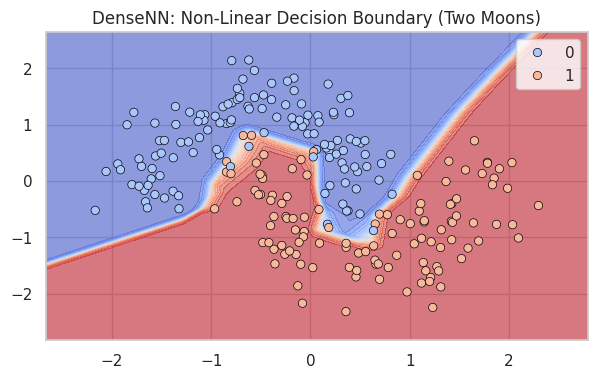

In [9]:
# Visualize the learned non-linear decision boundary
xx, yy = np.meshgrid(
    np.linspace(Xtr_s[:,0].min()-0.5, Xtr_s[:,0].max()+0.5, 200),
    np.linspace(Xtr_s[:,1].min()-0.5, Xtr_s[:,1].max()+0.5, 200)
)
grid_preds = net.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, grid_preds, levels=20, cmap="coolwarm", alpha=0.6)
sns.scatterplot(x=Xtr_s[:,0], y=Xtr_s[:,1], hue=ytr.flatten(), palette="coolwarm", edgecolor="black")
plt.title("DenseNN: Non-Linear Decision Boundary (Two Moons)")
plt.show()


## 8. Batch vs Mini-Batch vs Stochastic Gradient Descent

| Variant | Batch Size | Characteristics |
|---|---|---|
| **Batch Gradient Descent** | Entire dataset | Stable but slow, one update per epoch |
| **Stochastic Gradient Descent (SGD)** | 1 sample | Fast, noisy updates, can escape local minima |
| **Mini-Batch Gradient Descent** | Small batch (e.g. 16–256) | Best of both — the standard in practice |

Let's compare their convergence on the same dataset.


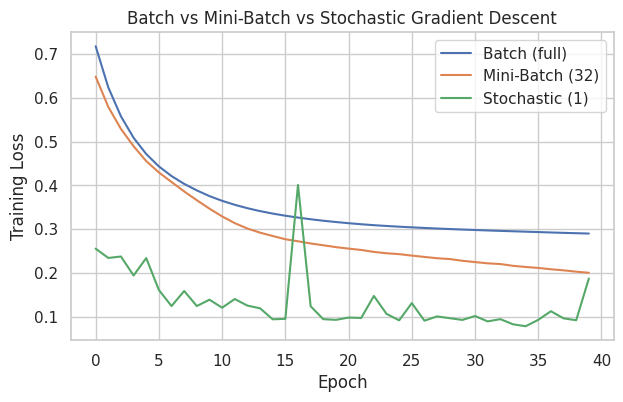

In [10]:
batch_sizes = {"Batch (full)": len(Xtr_s), "Mini-Batch (32)": 32, "Stochastic (1)": 1}
histories = {}

for name, bs in batch_sizes.items():
    net_variant = DenseNN([2, 16, 8, 1], ["relu", "relu", "sigmoid"], optimizer="sgd", lr=0.1, init="he")
    h = net_variant.fit(Xtr_s, ytr, epochs=40, batch_size=bs, loss="bce")
    histories[name] = h["train_loss"]

plt.figure()
for name, loss_hist in histories.items():
    plt.plot(loss_hist, label=name)
plt.title("Batch vs Mini-Batch vs Stochastic Gradient Descent")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()


## 9. Epochs, Batch Size, Iterations

| Term | Meaning |
|---|---|
| **Epoch** | One full pass through the entire training dataset |
| **Batch Size** | Number of samples processed before updating weights once |
| **Iteration** | One weight update (one batch processed) |

```
iterations per epoch = ceil(training_samples / batch_size)
```


In [11]:
training_samples = len(Xtr_s)
for bs in [1, 16, 32, len(Xtr_s)]:
    iters = int(np.ceil(training_samples / bs))
    print(f"Batch size {bs:>4} -> {iters:>3} iterations per epoch")


Batch size    1 -> 240 iterations per epoch
Batch size   16 ->  15 iterations per epoch
Batch size   32 ->   8 iterations per epoch
Batch size  240 ->   1 iterations per epoch


## 10. Optimizers — SGD, Momentum, RMSProp, Adam

| Optimizer | Idea |
|---|---|
| **SGD** | Plain gradient descent step |
| **Momentum** | Accumulates a moving average of past gradients to accelerate in consistent directions |
| **RMSProp** | Divides the learning rate by a moving average of squared gradients (adaptive per-parameter LR) |
| **Adam** | Combines Momentum + RMSProp — the most widely used optimizer today |

We'll visualize how each optimizer navigates a simple 2D loss surface (a bowl with steep and shallow directions).


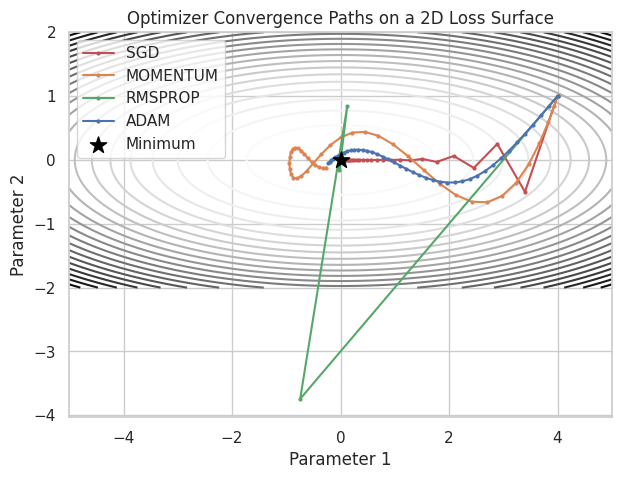

In [12]:
def loss_surface(x, y):
    return 0.5 * x**2 + 5 * y**2  # steep in y, shallow in x

def grad_surface(x, y):
    return np.array([x, 10 * y])

def run_optimizer(opt_name, lr=0.1, steps=40, start=(4.0, 1.0)):
    pos = np.array(start, dtype=float)
    path = [pos.copy()]
    m, v = np.zeros(2), np.zeros(2)
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    for t in range(1, steps + 1):
        g = grad_surface(*pos)
        if opt_name == "sgd":
            pos = pos - lr * g
        elif opt_name == "momentum":
            m = beta1 * m + (1 - beta1) * g
            pos = pos - lr * m
        elif opt_name == "rmsprop":
            v = beta2 * v + (1 - beta2) * g**2
            pos = pos - lr * g / (np.sqrt(v) + eps)
        elif opt_name == "adam":
            m = beta1 * m + (1 - beta1) * g
            v = beta2 * v + (1 - beta2) * g**2
            m_hat = m / (1 - beta1**t)
            v_hat = v / (1 - beta2**t)
            pos = pos - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(pos.copy())
    return np.array(path)

xg, yg = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-2, 2, 100))
Z = loss_surface(xg, yg)

plt.figure(figsize=(7, 5))
plt.contour(xg, yg, Z, levels=25, cmap="Greys")
colors = {"sgd": "#C44E52", "momentum": "#DD8452", "rmsprop": "#55A868", "adam": "#4C72B0"}
for opt_name, color in colors.items():
    path = run_optimizer(opt_name, lr=0.15)
    plt.plot(path[:, 0], path[:, 1], marker="o", markersize=2, label=opt_name.upper(), color=color)
plt.scatter([0], [0], color="black", marker="*", s=150, label="Minimum", zorder=5)
plt.title("Optimizer Convergence Paths on a 2D Loss Surface")
plt.xlabel("Parameter 1")
plt.ylabel("Parameter 2")
plt.legend()
plt.show()


Notice how **Momentum** and **Adam** reach the minimum faster and with less oscillation than plain
**SGD**, while **RMSProp** adapts its step size per-dimension based on the steepness of the surface.


## 11. Weight Initialization (Xavier, He)

Poor initialization can stall training entirely:

- **Zero initialization** — all neurons learn identical features (symmetry never breaks). Bad.
- **Xavier/Glorot init** — variance = 1/fan_in. Works well with **sigmoid/tanh**.
- **He init** — variance = 2/fan_in. Works well with **ReLU** (accounts for ReLU zeroing out half the inputs).


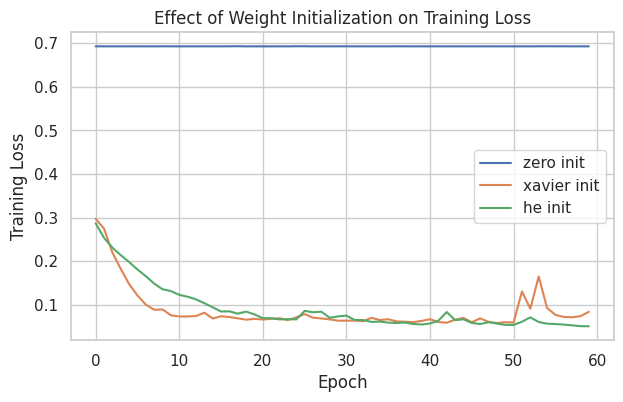

In [13]:
inits = ["zero", "xavier", "he"]
init_histories = {}

for init in inits:
    net_i = DenseNN([2, 16, 16, 1], ["relu", "relu", "sigmoid"], optimizer="adam", lr=0.03, init=init)
    h = net_i.fit(Xtr_s, ytr, epochs=60, batch_size=32, loss="bce")
    init_histories[init] = h["train_loss"]

plt.figure()
for name, h in init_histories.items():
    plt.plot(h, label=f"{name} init")
plt.title("Effect of Weight Initialization on Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.show()


**Zero initialization** gets stuck immediately (loss barely moves) because every neuron in a layer
receives an identical gradient and stays identical forever. **Xavier** and **He** both break symmetry
and converge — He is generally preferred for ReLU networks.


## 12. Vanishing & Exploding Gradients

- **Vanishing Gradients** — in deep networks with saturating activations (sigmoid/tanh), gradients
  shrink as they're multiplied backward through many layers, so early layers barely learn.
- **Exploding Gradients** — the opposite: gradients grow uncontrollably, causing unstable updates
  (often mitigated with **gradient clipping**).

We can see the vanishing effect directly by tracking gradient magnitude at each layer of a deep
sigmoid network.


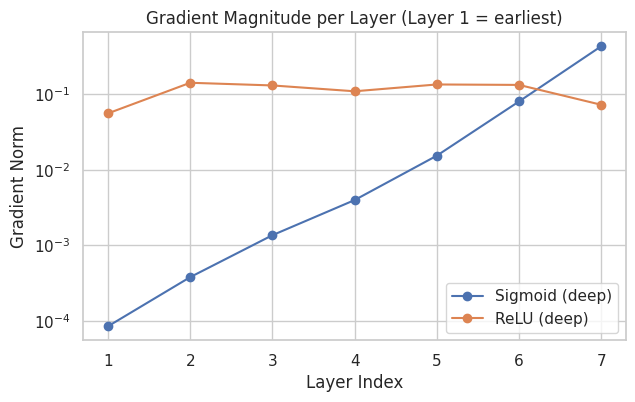

In [14]:
def track_gradient_norms(activation, depth=6):
    layer_sizes = [2] + [16]*depth + [1]
    activations = [activation]*depth + ["sigmoid"]
    net_deep = DenseNN(layer_sizes, activations, optimizer="sgd", lr=0.1, init="xavier")
    net_deep.forward(Xtr_s, training=True)
    dW, db = net_deep.backward(Xtr_s, ytr, loss="bce")
    return [np.linalg.norm(dw) for dw in dW]

grad_norms_sigmoid = track_gradient_norms("sigmoid", depth=6)
grad_norms_relu = track_gradient_norms("relu", depth=6)

plt.figure()
plt.plot(range(1, len(grad_norms_sigmoid)+1), grad_norms_sigmoid, marker="o", label="Sigmoid (deep)")
plt.plot(range(1, len(grad_norms_relu)+1), grad_norms_relu, marker="o", label="ReLU (deep)")
plt.title("Gradient Magnitude per Layer (Layer 1 = earliest)")
plt.xlabel("Layer Index")
plt.ylabel("Gradient Norm")
plt.yscale("log")
plt.legend()
plt.show()


With **Sigmoid**, gradient magnitude collapses toward the earliest layers — the classic **vanishing
gradient** problem. **ReLU** keeps gradients much larger and more stable across depth, which is why
it's the default choice for deep hidden layers today.


## 13. Preventing Overfitting

### 13.1 Dropout
Randomly "turns off" a fraction of neurons during each training step, forcing the network to not
rely on any single neuron — implemented above in `DenseNN` via the `dropout` parameter.

### 13.2 L1 / L2 Regularization
Adds a penalty on large weights to the loss, encouraging simpler models. `DenseNN`'s `l2` parameter
adds `L2 * W` to the weight gradient (equivalent to weight decay).

### 13.3 Early Stopping
Stop training once validation loss stops improving — prevents the model from memorizing the training set.

### 13.4 Batch Normalization
Normalizes each layer's inputs (zero mean, unit variance) during training, which stabilizes and
speeds up training and has a mild regularizing effect.


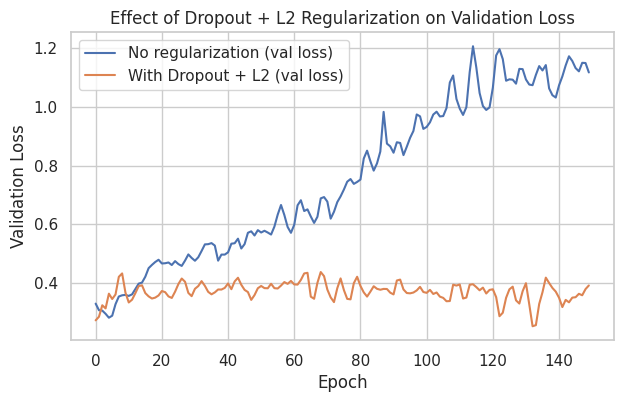

In [15]:
# Dropout & L2 in action: compare an overfitting-prone network with and without regularization
X_small, y_small = make_moons(n_samples=80, noise=0.35, random_state=7)  # small + noisy -> easy to overfit
y_small = y_small.reshape(-1, 1)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_small, y_small, test_size=0.3, random_state=7)
sc = StandardScaler().fit(Xs_tr)
Xs_tr, Xs_te = sc.transform(Xs_tr), sc.transform(Xs_te)

configs = {
    "No regularization": dict(l2=0.0, dropout=0.0),
    "With Dropout + L2": dict(l2=0.05, dropout=0.2),
}

plt.figure()
for name, cfg in configs.items():
    net_reg = DenseNN([2, 32, 32, 1], ["relu", "relu", "sigmoid"], optimizer="adam", lr=0.02, init="he", **cfg)
    h = net_reg.fit(Xs_tr, ys_tr, epochs=150, batch_size=16, loss="bce", X_val=Xs_te, y_val=ys_te)
    plt.plot(h["val_loss"], label=f"{name} (val loss)")

plt.title("Effect of Dropout + L2 Regularization on Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()


Early stopping at epoch 10 (best val_loss=0.2529)


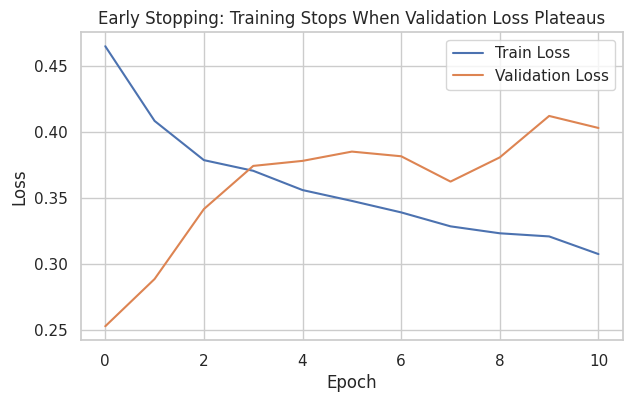

In [16]:
# Early Stopping demo: stop training when validation loss stops improving
def fit_with_early_stopping(net, X, y, X_val, y_val, epochs=200, patience=10, batch_size=16, loss="bce"):
    best_val = np.inf
    wait = 0
    history = {"train_loss": [], "val_loss": []}
    n = X.shape[0]
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            Xb, yb = X[idx[start:start+batch_size]], y[idx[start:start+batch_size]]
            net.forward(Xb, training=True)
            dW, db = net.backward(Xb, yb, loss=loss)
            net.update(dW, db)
        train_loss = net.compute_loss(y, net.forward(X, training=False), loss=loss)
        val_loss = net.compute_loss(y_val, net.forward(X_val, training=False), loss=loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if val_loss < best_val - 1e-4:
            best_val = val_loss
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch} (best val_loss={best_val:.4f})")
                break
    return history

net_es = DenseNN([2, 32, 32, 1], ["relu", "relu", "sigmoid"], optimizer="adam", lr=0.02, init="he")
h_es = fit_with_early_stopping(net_es, Xs_tr, ys_tr, Xs_te, ys_te, epochs=200, patience=10)

plt.figure()
plt.plot(h_es["train_loss"], label="Train Loss")
plt.plot(h_es["val_loss"], label="Validation Loss")
plt.title("Early Stopping: Training Stops When Validation Loss Plateaus")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


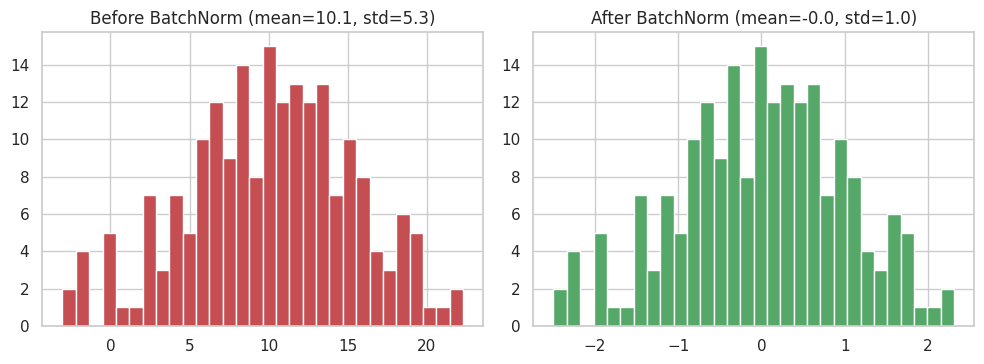

In [17]:
# Batch Normalization — simplified forward-pass demonstration
def batch_norm(Z, gamma=1.0, beta=0.0, eps=1e-8):
    mu = Z.mean(axis=0, keepdims=True)
    var = Z.var(axis=0, keepdims=True)
    Z_norm = (Z - mu) / np.sqrt(var + eps)
    return gamma * Z_norm + beta

Z_demo = np.random.randn(200, 1) * 5 + 10  # mean~10, std~5 (unnormalized layer output)
Z_bn = batch_norm(Z_demo)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].hist(Z_demo, bins=30, color="#C44E52")
axes[0].set_title(f"Before BatchNorm (mean={Z_demo.mean():.1f}, std={Z_demo.std():.1f})")
axes[1].hist(Z_bn, bins=30, color="#55A868")
axes[1].set_title(f"After BatchNorm (mean={Z_bn.mean():.1f}, std={Z_bn.std():.1f})")
plt.tight_layout()
plt.show()


## 14. Learning Rate & Learning Rate Scheduling

The **Learning Rate** controls how big each weight update step is:

- Too high → training overshoots and diverges
- Too low → training is very slow

**Learning Rate Scheduling** starts with a larger LR for fast initial progress, then decays it over
time for fine-grained convergence. Common schedules: **step decay**, **exponential decay**.


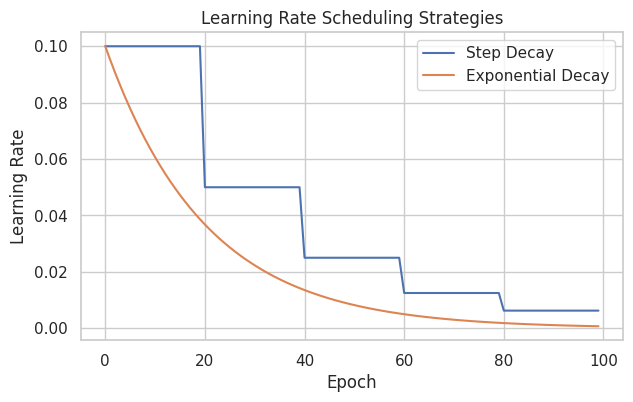

In [18]:
def step_decay(initial_lr, epoch, drop=0.5, epochs_drop=20):
    return initial_lr * (drop ** np.floor(epoch / epochs_drop))

def exponential_decay(initial_lr, epoch, k=0.05):
    return initial_lr * np.exp(-k * epoch)

epochs_range = np.arange(0, 100)
plt.figure()
plt.plot(epochs_range, [step_decay(0.1, e) for e in epochs_range], label="Step Decay")
plt.plot(epochs_range, [exponential_decay(0.1, e) for e in epochs_range], label="Exponential Decay")
plt.title("Learning Rate Scheduling Strategies")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.show()


## 15. Hyperparameter Tuning

Key hyperparameters to tune: number of layers, neurons per layer, learning rate, batch size, dropout
rate, optimizer choice. A common approach is **Grid Search** with cross-validation using
Scikit-learn's `MLPClassifier`.


In [19]:
param_grid = {
    "hidden_layer_sizes": [(16,), (32, 16)],
    "alpha": [0.0001, 0.01],          # L2 regularization strength
    "learning_rate_init": [0.01, 0.05],
}

grid = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    param_grid, cv=3, scoring="accuracy"
)
grid.fit(Xtr_s, ytr.ravel())

print("Best parameters:", grid.best_params_)
print("Best cross-validation accuracy:", round(grid.best_score_, 3))


Best parameters: {'alpha': 0.01, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.05}
Best cross-validation accuracy: 0.95


---
## 16. Practice — ANN for Classification (Scikit-learn `MLPClassifier`)

Applying everything above through a production-grade library workflow.


In [20]:
X_clf, y_clf = make_classification(
    n_samples=500, n_features=10, n_informative=6, n_redundant=2,
    n_classes=2, random_state=42
)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
sc_c = StandardScaler().fit(Xc_tr)
Xc_tr, Xc_te = sc_c.transform(Xc_tr), sc_c.transform(Xc_te)

clf = MLPClassifier(
    hidden_layer_sizes=(32, 16), activation="relu", solver="adam",
    alpha=0.001, learning_rate_init=0.01, max_iter=500,
    early_stopping=True, random_state=42
)
clf.fit(Xc_tr, yc_tr)
preds_clf = clf.predict(Xc_te)

print("Accuracy: ", round(accuracy_score(yc_te, preds_clf), 3))
print("Precision:", round(precision_score(yc_te, preds_clf), 3))
print("Recall:   ", round(recall_score(yc_te, preds_clf), 3))
print("F1 Score: ", round(f1_score(yc_te, preds_clf), 3))


Accuracy:  0.88
Precision: 0.964
Recall:    0.841
F1 Score:  0.898


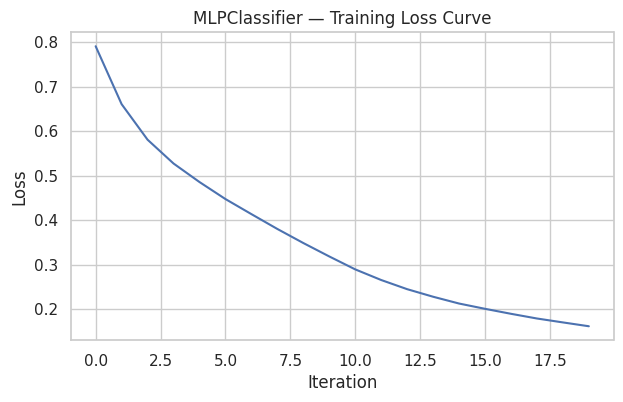

In [21]:
plt.figure()
plt.plot(clf.loss_curve_)
plt.title("MLPClassifier — Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()


## 17. Practice — ANN for Regression (Scikit-learn `MLPRegressor`)


In [22]:
X_reg, y_reg = make_regression(n_samples=500, n_features=8, noise=15, random_state=42)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
sc_r = StandardScaler().fit(Xr_tr)
Xr_tr, Xr_te = sc_r.transform(Xr_tr), sc_r.transform(Xr_te)

reg = MLPRegressor(
    hidden_layer_sizes=(32, 16), activation="relu", solver="adam",
    alpha=0.001, learning_rate_init=0.01, max_iter=1000,
    early_stopping=True, random_state=42
)
reg.fit(Xr_tr, yr_tr)
preds_reg = reg.predict(Xr_te)

print("MAE: ", round(mean_absolute_error(yr_te, preds_reg), 3))
print("MSE: ", round(mean_squared_error(yr_te, preds_reg), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(yr_te, preds_reg)), 3))
print("R2:  ", round(r2_score(yr_te, preds_reg), 3))


MAE:  12.962
MSE:  264.8
RMSE: 16.273
R2:   0.986


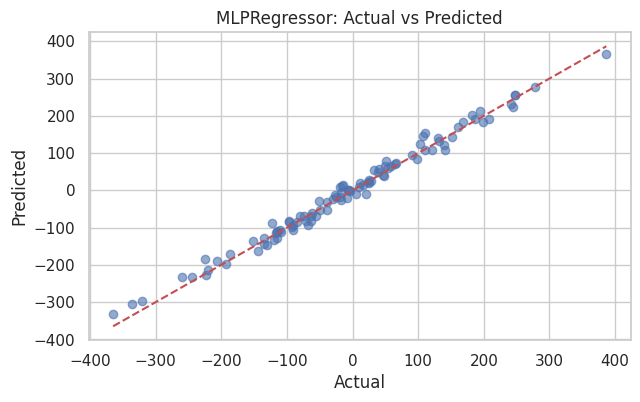

In [23]:
plt.figure()
plt.scatter(yr_te, preds_reg, alpha=0.6, color="#4C72B0")
plt.plot([yr_te.min(), yr_te.max()], [yr_te.min(), yr_te.max()], "--", color="#C44E52")
plt.title("MLPRegressor: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


---
## 🔑 Key Takeaways

- A neural network is layers of neurons computing `activation(W·x + b)`, trained end-to-end.
- **Activation functions** (Sigmoid, Tanh, ReLU, Leaky ReLU, Softmax) introduce the non-linearity that lets networks learn complex functions.
- **Forward propagation** produces predictions; **backpropagation** (chain rule) computes how to fix the weights; **gradient descent** applies the fix.
- **Batch / Mini-Batch / Stochastic** gradient descent trade off stability vs speed — mini-batch is the practical default.
- **Optimizers** (SGD, Momentum, RMSProp, Adam) change *how* the gradient is applied — Adam is the most widely used default.
- **Weight initialization** (He for ReLU, Xavier for Sigmoid/Tanh) prevents training from stalling at the start.
- **Vanishing/exploding gradients** are a depth problem — ReLU and careful initialization mitigate vanishing gradients.
- **Dropout, L1/L2 regularization, Early Stopping, and Batch Normalization** all fight overfitting from different angles.
- **Learning rate scheduling** balances fast early progress with stable late-stage convergence.
- Hyperparameter tuning (layers, neurons, LR, batch size, regularization) is what turns a working network into a *good* one.

**Next up (Module 5, Day 2):** Convolutional Neural Networks (CNNs) — how deep learning processes images.
